# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [16]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt
from PIL import ImageOps

%matplotlib inline

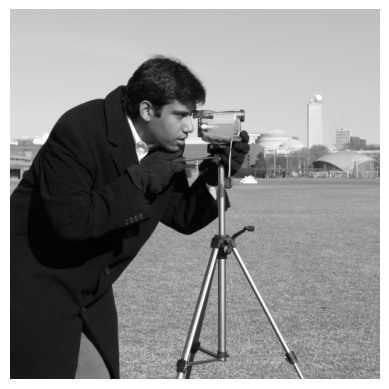

In [3]:
image = data.camera()

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
image = Image.fromarray(image)

# Get the size of the image
width, height = image.size

# scaling factors
scale_x = 2
scale_y = 2

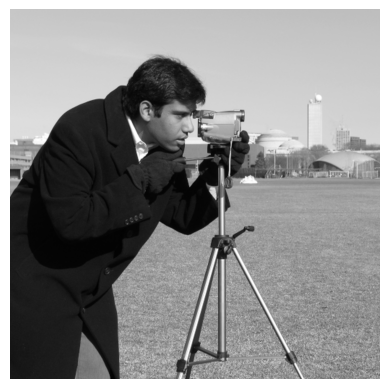

In [8]:
scaled_image = image.resize((width * 2, height * 2), Image.Resampling.LANCZOS)

plt.imshow(scaled_image, cmap="gray")
plt.axis("off")
plt.show()

In [7]:

# Save the scaled image and print the sizes
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("New size:", scaled_image.size)

Original size: (512, 512)
New size: (1024, 1024)


**bold text** non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [9]:
scaled_nonuniform = image.resize(
    (width * 2, height * 1),
    Image.Resampling.LANCZOS
)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


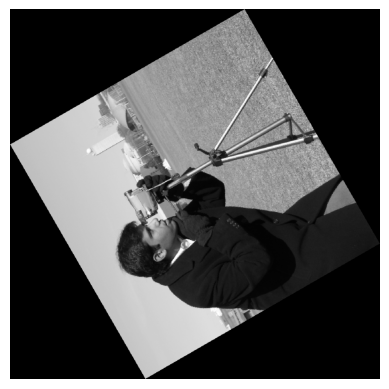

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(120, expand=True)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
# Save the rotated image and print the sizes
rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

plt.imshow(rotated_image, cmap="gray")
plt.axis("off")
plt.show()

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [12]:
# -- d. define the shear matrix ──────────────────────────
shear_matrix = (1, 0.5, 0, 0, 1, 0)
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = (1, shear_factor, 0, 0, 1, 0)

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
# -- e. Apply the shear transformation to the image ──────────────────────────
sheared_image = image.transform(
    (width, height),
    Image.Transform.AFFINE,
    (1, -shear_factor, 0, 0, 1, 0)
)

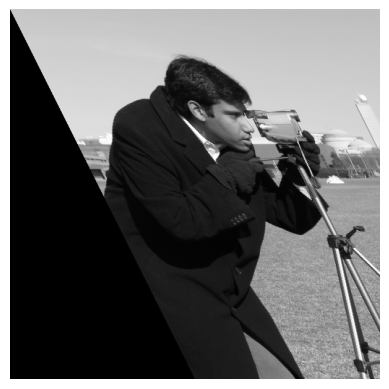

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
# -- f. Save the sheared image
sheared_image.save("task1_3_sheared.jpg")

plt.imshow(sheared_image, cmap="gray")
plt.axis("off")
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [15]:

# Convert image to NumPy array
img_array = np.array(image)

# Create negative image
negative = 255 - img_array


In [17]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)

In [18]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_image = c * np.log(1 + np.array(image))

# Convert back to uint8
log_image = np.uint8(log_image)

/tmp/ipykernel_2939/1735577360.py:7: RuntimeWarning: divide by zero encountered in log
  log_image = c * np.log(1 + np.array(image))
/tmp/ipykernel_2939/1735577360.py:10: RuntimeWarning: invalid value encountered in cast
  log_image = np.uint8(log_image)


In [19]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

img_array = np.array(image).astype(np.float32) / 255.0

gamma_image = np.power(img_array, gamma)

gamma_image = np.uint8(gamma_image * 255)

Gamma: 0.5
Original size: (512, 512)
Gamma image size: (512, 512)


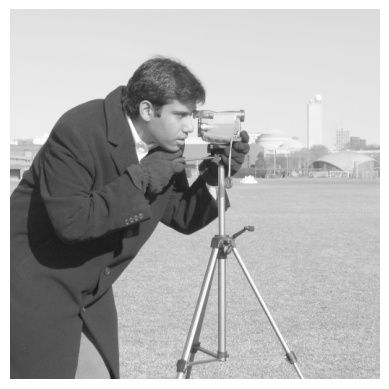

In [20]:
print("Gamma:", gamma)
print("Original size:", image.size)
print("Gamma image size:", gamma_image.shape)

plt.imshow(gamma_image, cmap="gray")
plt.axis("off")
plt.show()